In [1]:
import json
import requests
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
url = "http://chendeb.free.fr/infoclimat.json"

try:
    api_request = requests.get(url)
    data = json.loads(api_request.content)
except Exception as e:
    data = "Error..."

keys_to_remove = ['request_state', 'request_key', 'message', 'model_run', 'source']
for key in keys_to_remove:
    data.pop(key, None)

In [3]:
lesDates = [datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S") for date_str in data.keys()]
lesTempA2m = [data[date_str]['temperature']['2m'] - 273.15 for date_str in data.keys()]
lesTempAuSol = [data[date_str]['temperature']['sol'] - 273.15 for date_str in data.keys()]
lesHumiditesA2m = [data[date_str]['humidite']['2m'] for date_str in data.keys()]

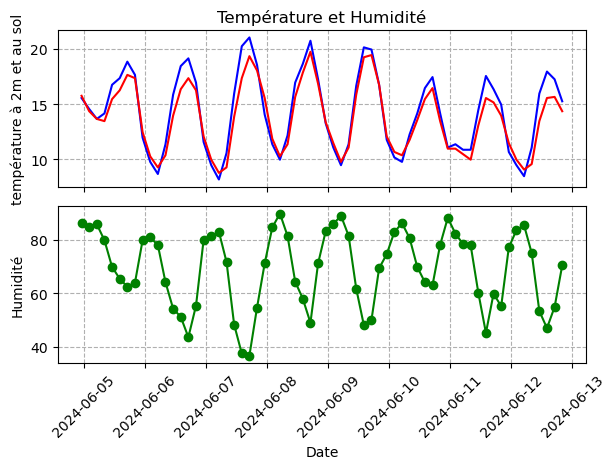

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(lesDates, lesTempA2m, color='blue', label='Temp 2m')
ax1.plot(lesDates, lesTempAuSol, color='red', label='Temp Sol')
ax1.set_ylabel('temp\u00e9rature \u00e0 2m et au sol')
ax1.set_title('Temp\u00e9rature et Humidit\u00e9')
ax1.grid(True, linestyle='--')

ax2.plot(lesDates, lesHumiditesA2m, color='green', marker='o')
ax2.set_ylabel('Humidit\u00e9')
ax2.set_xlabel('Date')
ax2.grid(True, linestyle='--')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
try:
    dfjson = pd.read_json(api_request.content, orient='index')
    dfjson = dfjson.drop(keys_to_remove, axis=0, errors='ignore')
    dfjson.index = pd.to_datetime(dfjson.index)
    dfsplited = pd.json_normalize(dfjson['temperature'])
    dfsplited.index = dfjson.index
except Exception as e:
    pass